In [420]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [421]:
cisne_branco = cv.imread("veleiro.jpg")
cisne_branco_norm = cisne_branco / 255 

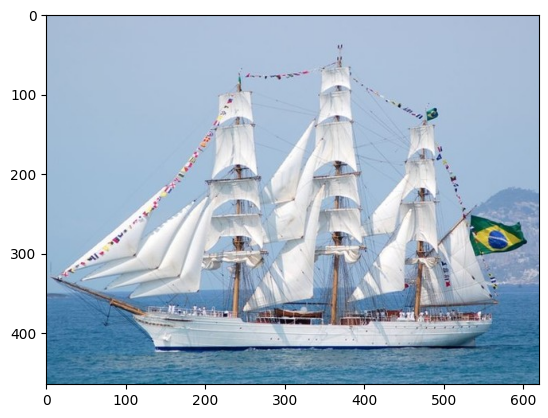

In [422]:
plt.imshow(cisne_branco[:,:,::-1])

In [423]:
pc = cv.imread("PoucoContraste.png")
pc = pc/255

# 1. Alterando Brilho e Contraste

In [424]:
def brigthness_contrast_modifier(img, alpha: float, beta: float = None):
    
    if -1<= alpha <= 1:
        imagem = img + alpha
        
    if beta:
        if 0 <= beta <= 1:
            if len(imagem.shape) > 2:
                for i in range(imagem.shape[2]):
                    chanel = imagem[:, :, i]
                    chanel = beta * (chanel - np.mean(chanel)) + np.mean(chanel)
                    imagem[:, :,i] =  chanel
            else:
                imagem = beta * (imagem - np.mean(imagem)) + np.mean(imagem)
    
    imagem = np.clip(imagem, 0, 1)
    return imagem

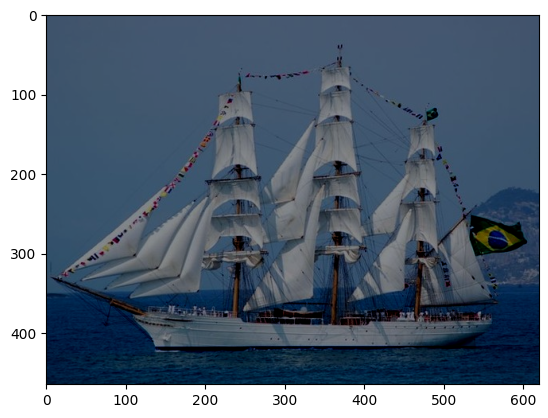

In [425]:
im = brigthness_contrast_modifier(cisne_branco_norm[:, :, ::-1], -0.4, 0.8)
plt.imshow(im)

# 2. Histograma

In [426]:
def plotar_comparativo_modifier(img, alpha: float, beta: float, imagem_normalizada: bool = False):
    
    fig, ax = plt.subplots(3, 3, figsize = (15, 15))
    
    img_luminancia_alt = brigthness_contrast_modifier(img, alpha= alpha, beta= 1)
    img_contraste_alt = brigthness_contrast_modifier(img, alpha= 0, beta= beta)

    b, g, r = cv.split(img)
    b1, g1, r1 = cv.split(img_luminancia_alt)
    b2, g2, r2 = cv.split(img_contraste_alt)

    chanels = [(b, g, r), (b1, g1, r1), (b2, g2, r2)]
    
    titles = ["Normal", f"Luminância (alpha = {alpha})", f"Constraste (beta = {beta})"]
    chanel_names = ["Azul", "Verde", "Vermelho"]


    for i in range(len(chanels)):
        for j in range(len(chanels[i])):
            if j == 0:
                ax[i,j].hist(chanels[i][j].flatten(), bins= 50, color= "blue", alpha=0.5)
                ax[i,j].set_title(titles[i])
            elif j == 1:
                ax[i,j].hist(chanels[i][j].flatten(), bins= 50, color= "green", alpha=0.5)
                ax[i,j].set_title(titles[i])
            elif j == 2:
                ax[i,j].hist(chanels[i][j].flatten(), bins= 50, color= "red", alpha=0.5)
                ax[i,j].set_title(titles[i])
            
            if imagem_normalizada:
                ax[i,j].set_xlim(0,1)
            else:
                ax[i,j].set_xlim(0,255)

    fig.suptitle("brightness_contrast_modifier", fontsize=16)
    plt.show()

In [427]:
def plotar_comparativo_opencv(img, alpha: float, beta: float, imagem_normalizada: bool = False):
    
    fig, ax = plt.subplots(3, 3, figsize = (15, 15))
    
    img_luminancia_alt = cv.convertScaleAbs(img, alpha= 1, beta= beta)
    img_contraste_alt = cv.convertScaleAbs(img, alpha= alpha, beta= 0)

    b, g, r = cv.split(img)
    b1, g1, r1 = cv.split(img_luminancia_alt)
    b2, g2, r2 = cv.split(img_contraste_alt)
    
    

    chanels = [(b, g, r), (b1, g1, r1), (b2, g2, r2)]
    
    titles = ["Normal", f"Luminância (beta = {beta})", f"Constraste (alpha = {alpha})"]
    chanel_names = ["Azul", "Verde", "Vermelho"]


    for i in range(len(chanels)):
        for j in range(len(chanels[i])):
            if j == 0:
                ax[i,j].hist(chanels[i][j].flatten(), bins= 50, color= "blue", alpha=0.5)
                ax[i,j].set_title(titles[i])
            elif j == 1:
                ax[i,j].hist(chanels[i][j].flatten(), bins= 50, color= "green", alpha=0.5)
                ax[i,j].set_title(titles[i])
            elif j == 2:
                ax[i,j].hist(chanels[i][j].flatten(), bins= 50, color= "red", alpha=0.5)
                ax[i,j].set_title(titles[i])
            
            if imagem_normalizada:
                ax[i,j].set_xlim(0,1)
            else:
                ax[i,j].set_xlim(0,255)
    
    fig.suptitle("convertScaleAbs", fontsize=16)
    plt.show()


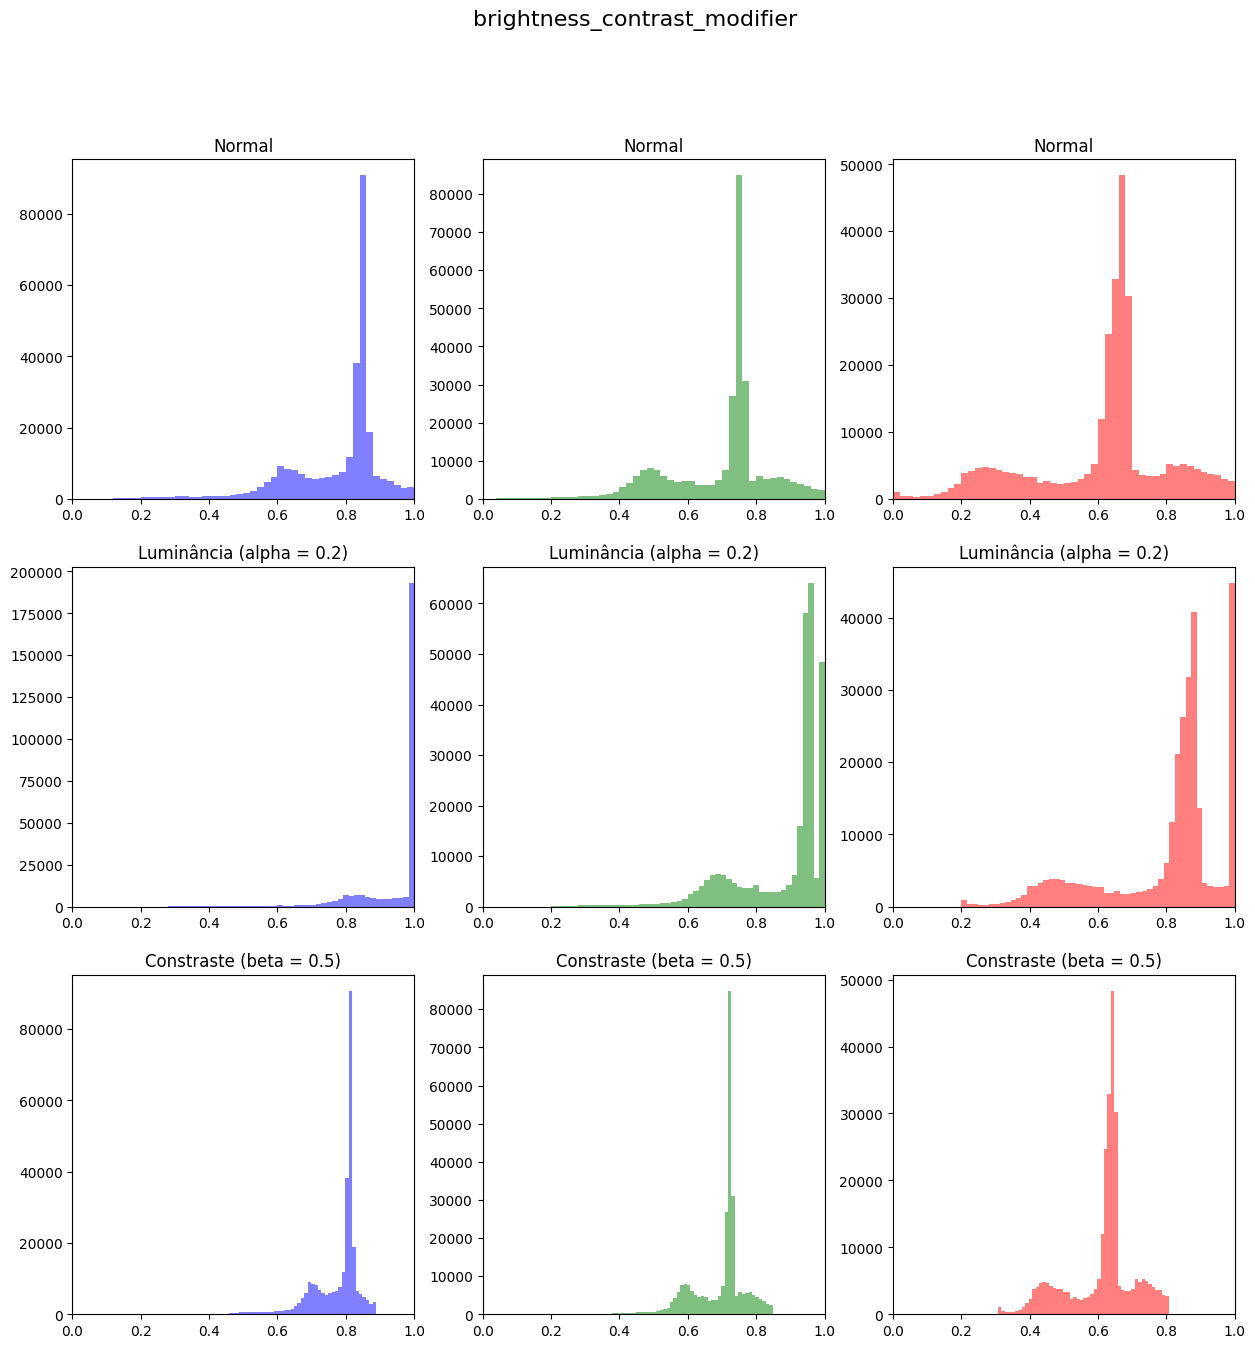

In [428]:
plotar_comparativo_modifier(cisne_branco_norm, alpha= 0.2, beta= 0.5, imagem_normalizada= True)

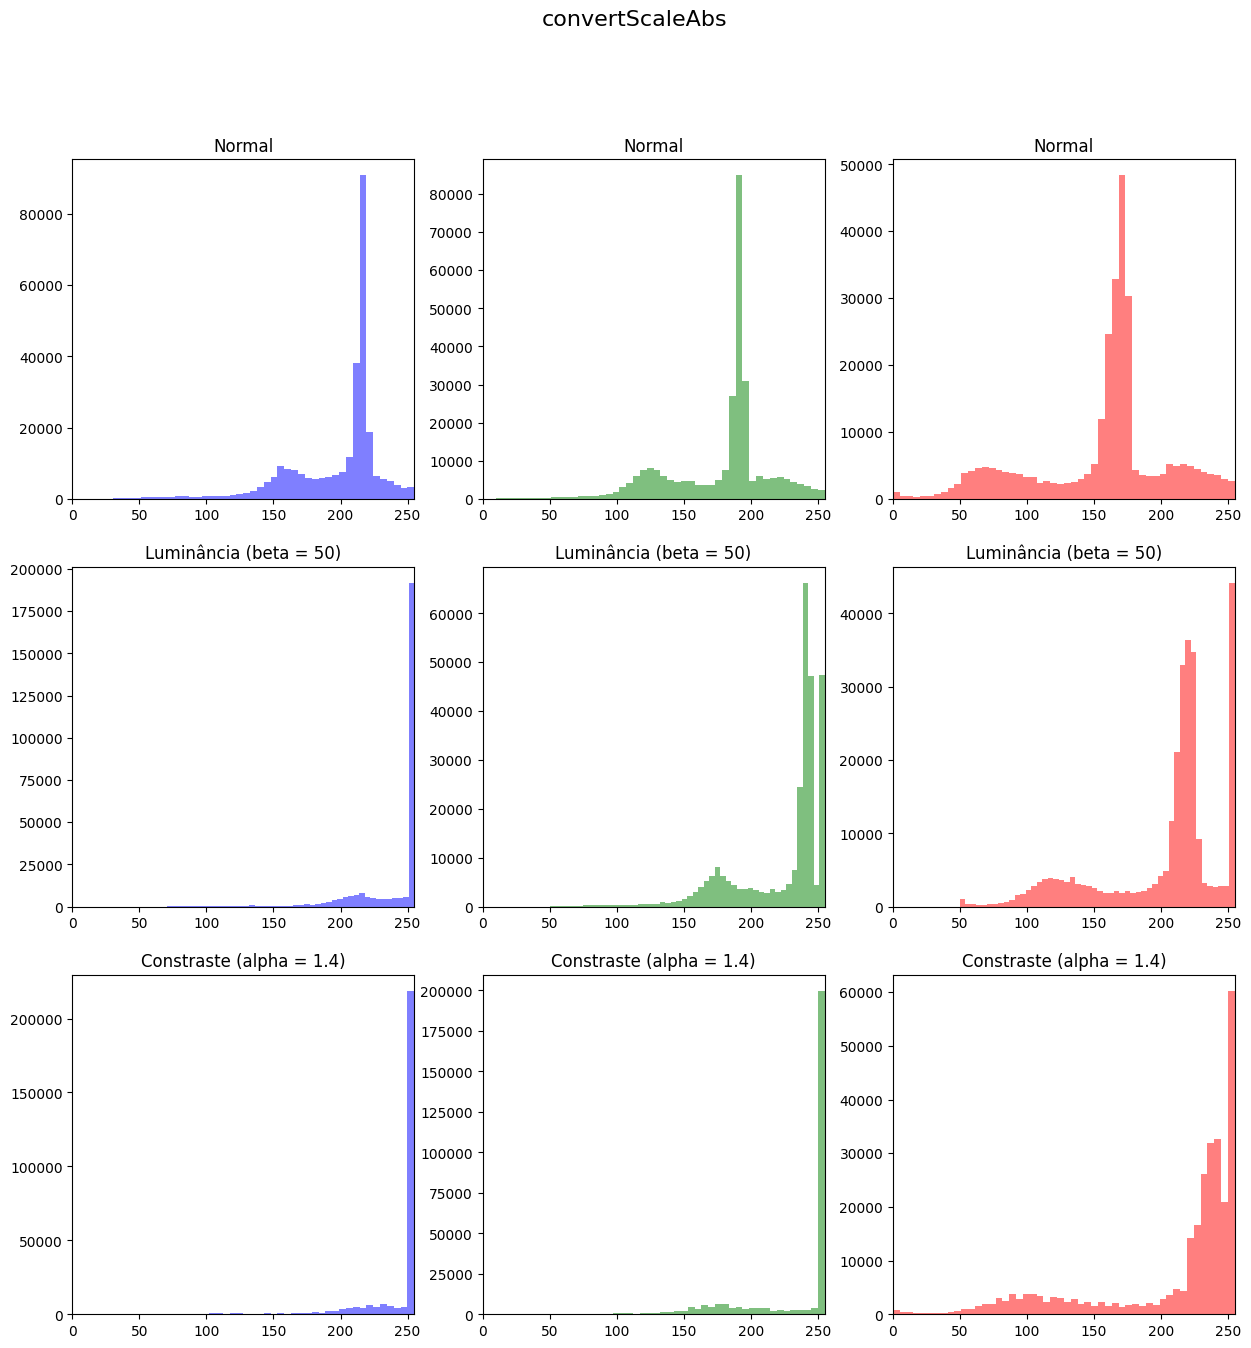

In [429]:
plotar_comparativo_opencv(cisne_branco, alpha= 1.4, beta= 50)

A função `brigthness_contrast_modifier` não implementa o mesmo conceito que a função `cv.convertScaleAbs` ao alterar o contraste, podemos perceber isso pelos gráficos, enquanto a nossa função parece achatar os valores dos nosso pixels em torno da média, a função do opencv apenas aumenta os seus valores. Isso se deve por conta da lógica de cálculo da função deles, cada pixel é calculado como: pixel = pixel * alpha + beta.

# 3. Cores

In [430]:
def proj_EscLin(img, imagem_normalizada: bool = False):
    imagem = img.astype(np.float32)
    b, g, r = cv.split(imagem)
    
    Y = r * 0.299 + g * 0.587 + b * 0.114 
    
    k = np.mean(Y)/Y
    
    imagem_proj = cv.merge((b*k, g*k, r*k))
    
    if imagem_normalizada:
        result = np.clip(imagem_proj, 0, 1)
    else:
        result = np.clip(imagem_proj, 0, 255).astype(np.uint8)
    
    
    return result
    

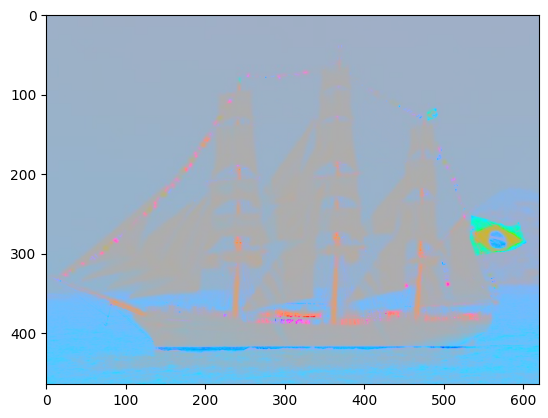

In [431]:
im_proj_EscLin = proj_EscLin(cisne_branco)
plt.imshow(im_proj_EscLin[:, :, ::-1])

In [432]:
def proj_Ort(img, imagem_normalizada: bool = False):
    imagem = img.astype(np.float32)
    b, g, r = cv.split(imagem)
    
    Y = r * 0.299 + g * 0.587 + b * 0.114 
    w = np.array([0.299, 0.587, 0.114])
    
    t = (np.mean(Y) - Y)/(w@w)
    
    imagem_proj = cv.merge((b + t*0.114, g + t*0.587, r + t*0.114))
    
    if imagem_normalizada:
        result = np.clip(imagem_proj, 0, 1)
    else:
        result = np.clip(imagem_proj, 0, 255).astype(np.uint8)
    
    
    return result
    


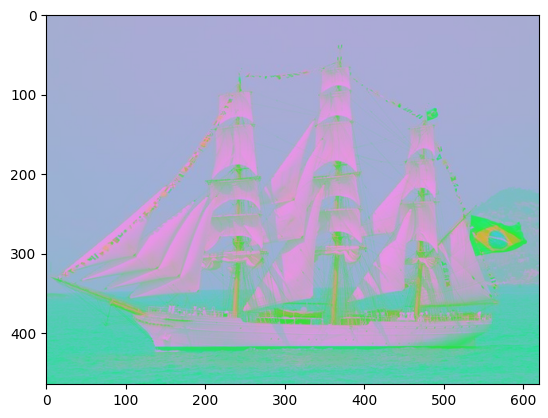

In [433]:
im_proj_Ort = proj_Ort(cisne_branco)
plt.imshow(im_proj_Ort[:, :, ::-1])

In [434]:
def plotar_comparativo(img_1, img_2, imagem_normalizada: bool = False):
    
    fig, ax = plt.subplots(2, 3, figsize = (15, 10))
    
    b1, g1, r1 = cv.split(img_1)
    b2, g2, r2 = cv.split(img_2)

    chanels = [(b1, g1, r1), (b2, g2, r2)]
    
    titles = ["Imagem 1", "Imagem 2"]


    for i in range(len(chanels)):
        for j in range(len(chanels[i])):
            if j == 0:
                ax[i,j].hist(chanels[i][j].flatten(), bins= 50, color= "blue", alpha=0.5)
                ax[i,j].set_title(titles[i])
            elif j == 1:
                ax[i,j].hist(chanels[i][j].flatten(), bins= 50, color= "green", alpha=0.5)
                ax[i,j].set_title(titles[i])
            elif j == 2:
                ax[i,j].hist(chanels[i][j].flatten(), bins= 50, color= "red", alpha=0.5)
                ax[i,j].set_title(titles[i])
            
            if imagem_normalizada:
                ax[i,j].set_xlim(0,1)
            else:
                ax[i,j].set_xlim(0,255)

    plt.show()

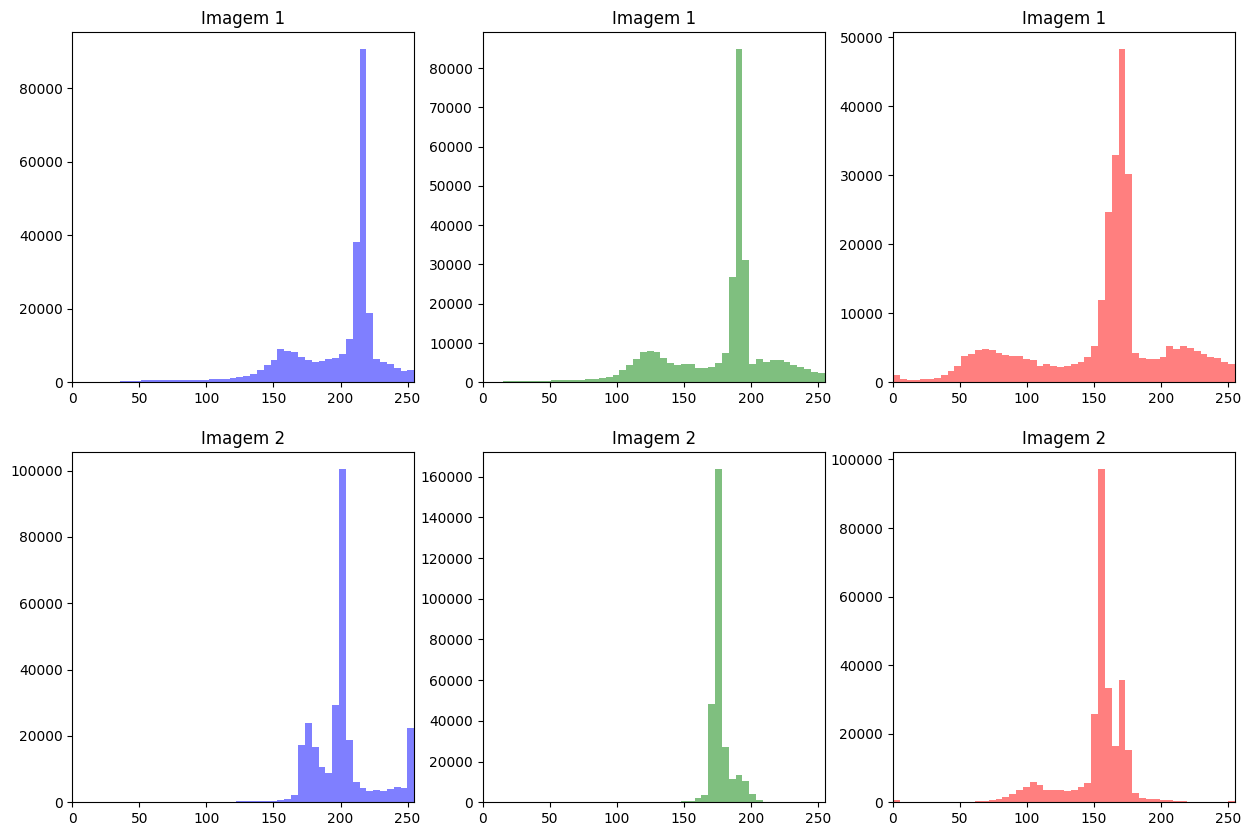

In [435]:
plotar_comparativo(cisne_branco, im_proj_EscLin)


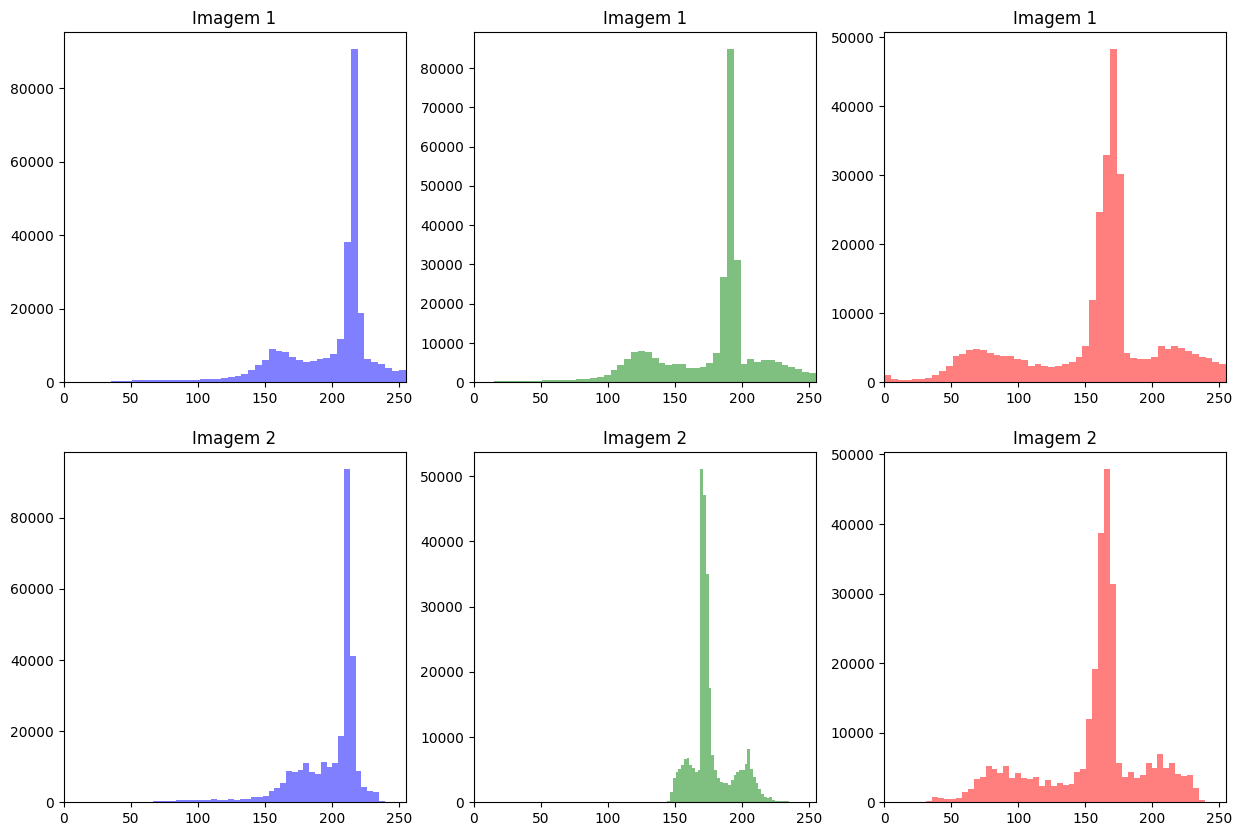

In [436]:
plotar_comparativo(cisne_branco, im_proj_Ort)

# 4. Filtros

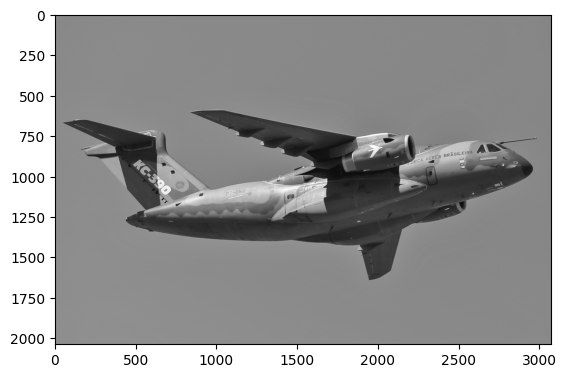

In [437]:
aviao = cv.imread("embraer_kc390.jpg", 0)
plt.imshow(aviao, cmap= "gray")

In [438]:
def aplicar_filtro(img, filtro):
    resultado = cv.filter2D(img, cv.CV_64F,  filtro)
    resultado = np.absolute(resultado)
    resultado = np.clip(resultado, 0, 255)
    return resultado.astype(np.uint8)

In [439]:
f_const = np.ones((3,3), dtype = np.float32) / 9

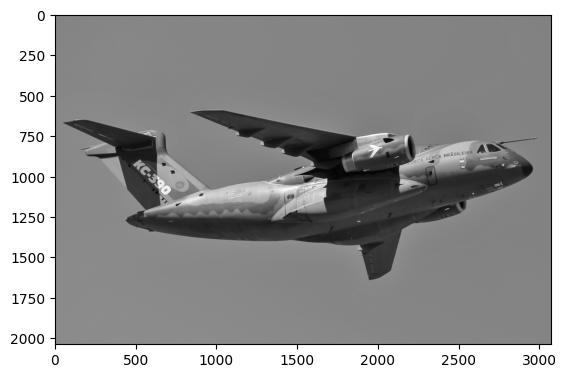

In [440]:
aviao_blur = aplicar_filtro(aviao, f_const)
plt.imshow(aviao_blur, cmap= "gray")

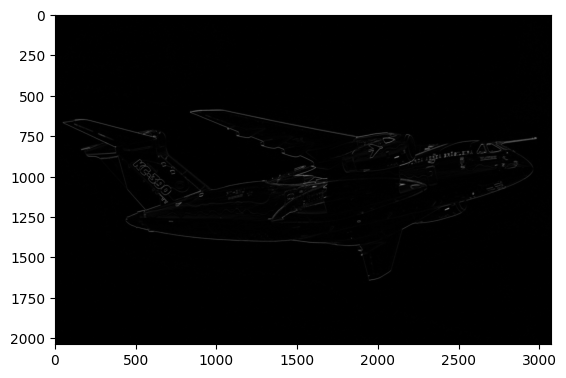

In [441]:
der_horizontal = np.array([-1, 0, 1], dtype= np.float32)
aviao_der_h = aplicar_filtro(aviao, der_horizontal)
plt.imshow(aviao_der_h, cmap= "gray")


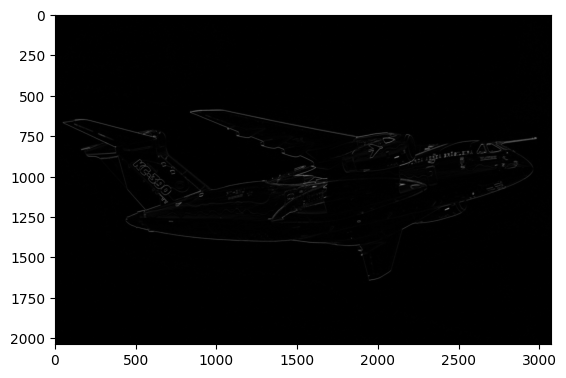

In [442]:
aviao_der_v = aplicar_filtro(aviao, np.transpose(der_horizontal))
plt.imshow(aviao_der_h, cmap= "gray")

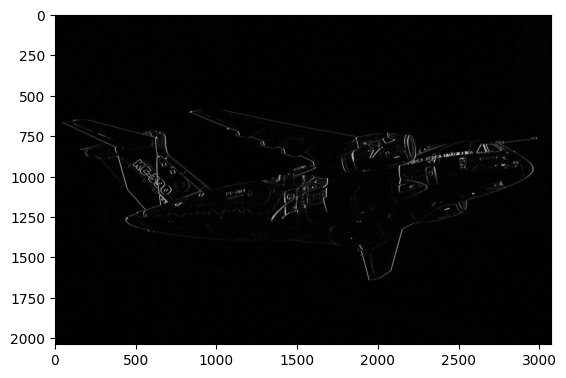

In [443]:
sobel_h = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype= np.float32)
aviao_sobel_h = aplicar_filtro(aviao, sobel_h)
plt.imshow(cv.convertScaleAbs(aviao_sobel_h), cmap= "gray")

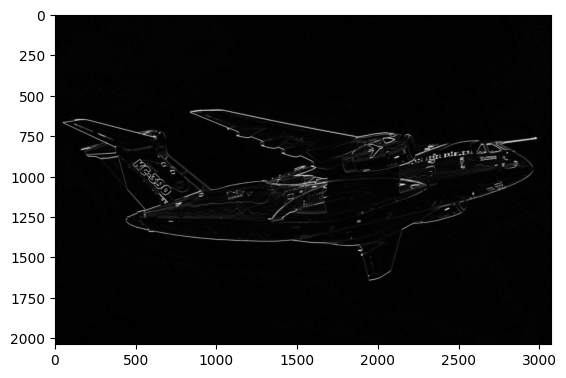

In [444]:
aviao_sobel_v = aplicar_filtro(aviao, np.transpose(sobel_h))
plt.imshow(cv.convertScaleAbs(aviao_sobel_v), cmap= "gray")

In [445]:
gradiente = np.sqrt(aviao_sobel_h^2 + aviao_sobel_v^2)

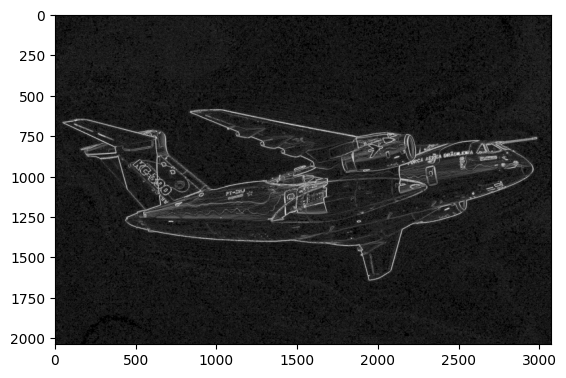

In [446]:
plt.imshow(gradiente, cmap= "gray")

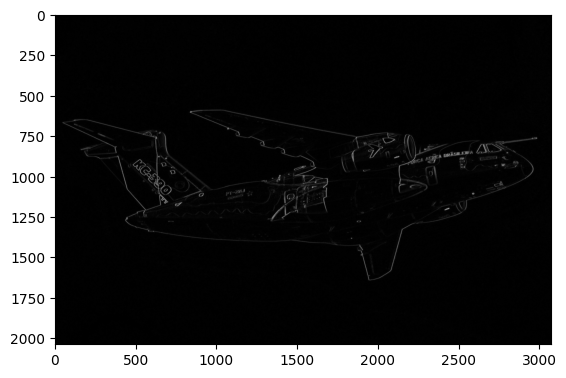

In [447]:
aviao_sobel_comb = cv.addWeighted(aviao_sobel_h, 0.5, aviao_der_v, 0.5, 0)
plt.imshow(cv.convertScaleAbs(aviao_sobel_comb), cmap= "gray")

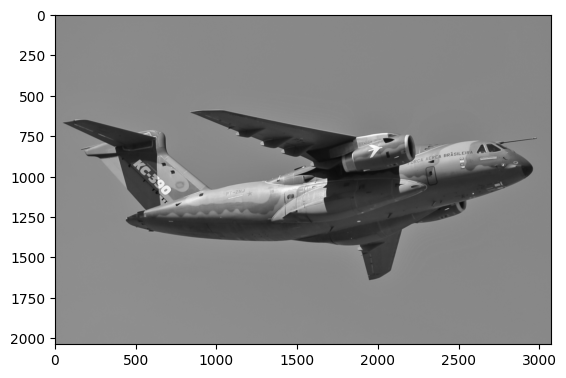

In [448]:
gaussian_matriz = cv.getGaussianKernel(5, np.sqrt(2))
aviao_gaussian = aplicar_filtro(aviao, gaussian_matriz)
plt.imshow(aviao_gaussian, cmap= "gray")

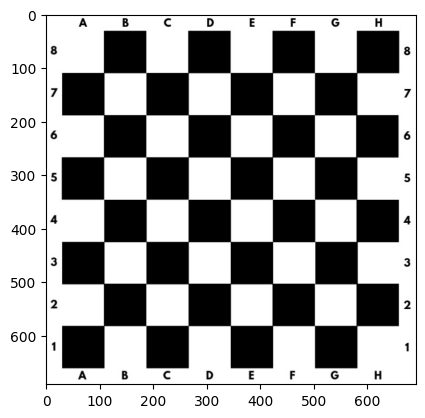

In [449]:
xadrez = cv.imread("xadrez.jpg", 0)
plt.imshow(xadrez, cmap= "gray")

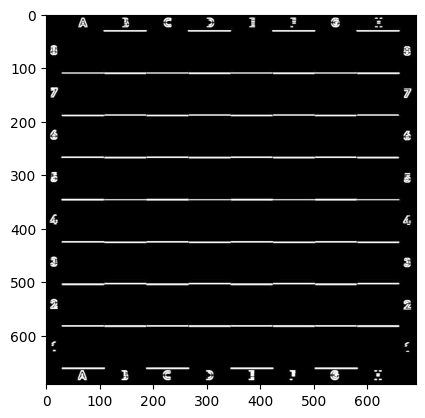

In [450]:
xadrez_sobel_v = aplicar_filtro(xadrez, np.transpose(sobel_h))
plt.imshow(xadrez_sobel_v, cmap= "gray")

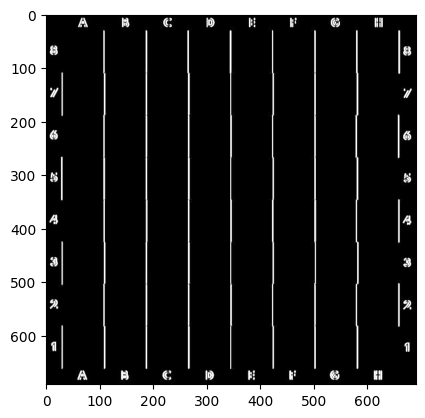

In [451]:
xadrez_sobel_h = aplicar_filtro(xadrez, sobel_h)
plt.imshow(xadrez_sobel_h, cmap= "gray")

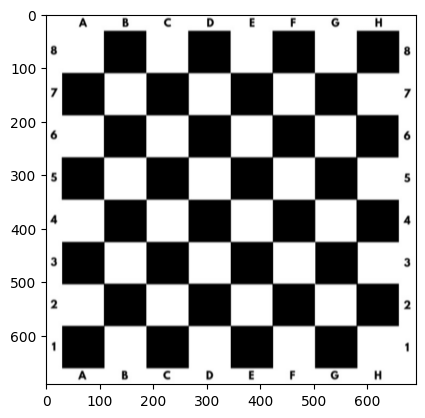

In [452]:
xadrez_gaussian = aplicar_filtro(xadrez, gaussian_matriz)
plt.imshow(xadrez_gaussian, cmap= "gray")

# 5. Redução de dimensão

In [465]:
def aplicar_redução_dim(img, step_x, step_y):
    imagem = img[::step_y, ::step_x]
    return imagem

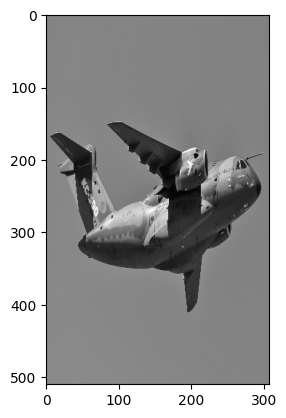

In [467]:
img_red = aplicar_redução_dim(aviao, 10, 4)
plt.imshow(img_red, cmap= "gray")